In [2]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_csv('/content/drive/MyDrive/employee attrition .csv')

In [5]:
selected_features = [
    "Age", "JobSatisfaction", "MonthlyIncome", "DistanceFromHome", "WorkLifeBalance",
    "YearsAtCompany", "OverTime", "JobInvolvement", "MaritalStatus",
    "PerformanceRating", "YearsSinceLastPromotion", "EmployeeNumber"
]

X = data[selected_features]
y = data["Attrition"]

In [6]:

# Handle missing values (replace with the mean for numerical features)
for col in X.select_dtypes(include=['number']):
    X[col].fillna(X[col].mean(), inplace=True)


X = pd.get_dummies(X, drop_first=True)
y = y.map({"Yes": 1, "No": 0})


/tmp/ipykernel_1625/141030296.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mean(), inplace=True)
/tmp/ipykernel_1625/141030296.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col].fillna(X[col].mean(), inplace=True)


In [7]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# prompt: apply normalization

from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled data back to DataFrames (optional but recommended)
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [9]:
# prompt: apply random forest on scaled

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
rf_predictions = rf_classifier.predict(X_test)

# Evaluate the model
print("Random Forest Classifier:")
print(classification_report(y_test, rf_predictions))
print(confusion_matrix(y_test, rf_predictions))


Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       259
           1       0.50      0.24      0.33        45

    accuracy                           0.85       304
   macro avg       0.69      0.60      0.62       304
weighted avg       0.82      0.85      0.83       304

[[248  11]
 [ 34  11]]


In [10]:
# prompt: apply logistic regression from scaled values

# Initialize and train the Logistic Regression model
logreg_classifier = LogisticRegression(random_state=42)
logreg_classifier.fit(X_train, y_train)

# Make predictions on the test set
logreg_predictions = logreg_classifier.predict(X_test)

# Evaluate the model
print("\nLogistic Regression:")
print(classification_report(y_test, logreg_predictions))
print(confusion_matrix(y_test, logreg_predictions))



Logistic Regression:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       259
           1       0.75      0.27      0.39        45

    accuracy                           0.88       304
   macro avg       0.82      0.63      0.66       304
weighted avg       0.87      0.88      0.85       304

[[255   4]
 [ 33  12]]


In [11]:
# Initialize and train the SVM classifier
svm_classifier = SVC(random_state=42)
svm_classifier.fit(X_train, y_train)

# Make predictions on the test set
svm_predictions = svm_classifier.predict(X_test)

# Evaluate the model
print("\nSVM Classifier:")
print(classification_report(y_test, svm_predictions))
print(confusion_matrix(y_test, svm_predictions))


SVM Classifier:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       259
           1       1.00      0.11      0.20        45

    accuracy                           0.87       304
   macro avg       0.93      0.56      0.56       304
weighted avg       0.89      0.87      0.82       304

[[259   0]
 [ 40   5]]


In [12]:
print(data.head())
print(data.info())
print(data.describe())
print(data.isnull().sum())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               3   
3                 3          4  Life Sciences              1               4   
4                 2          1        Medical              1               5   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

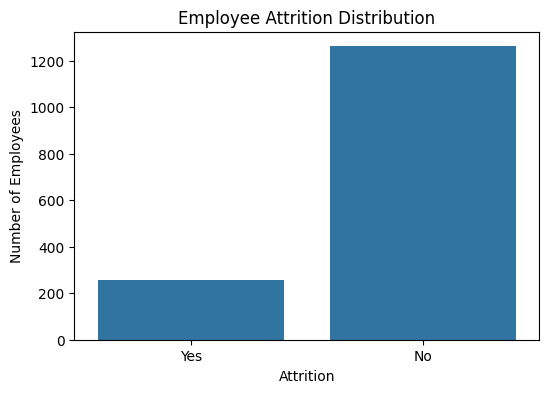

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=data)
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

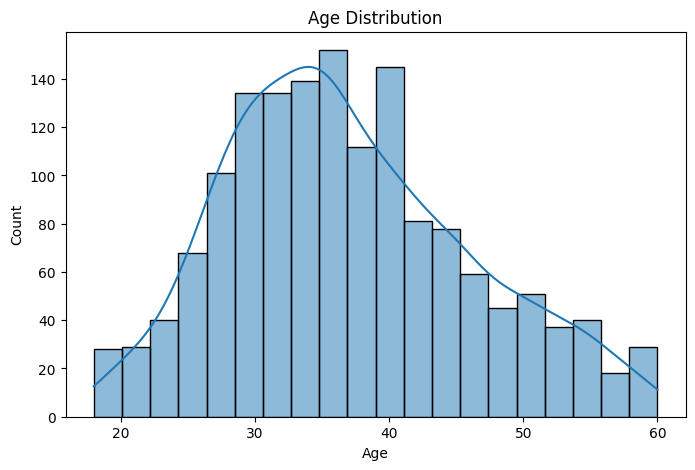

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(data['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

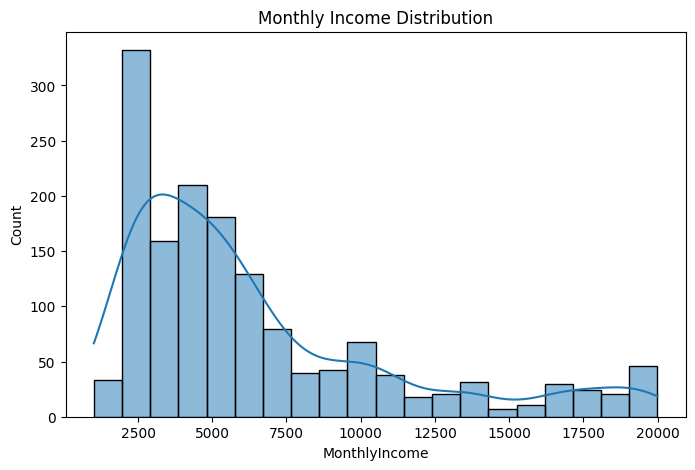

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(data['MonthlyIncome'], bins=20, kde=True)
plt.title("Monthly Income Distribution")
plt.show()

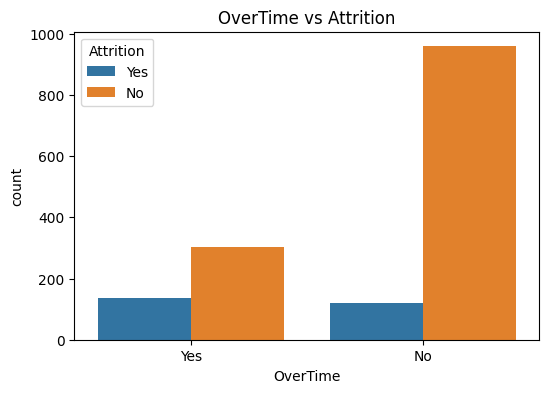

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='OverTime', hue='Attrition', data=data)
plt.title("OverTime vs Attrition")
plt.show()

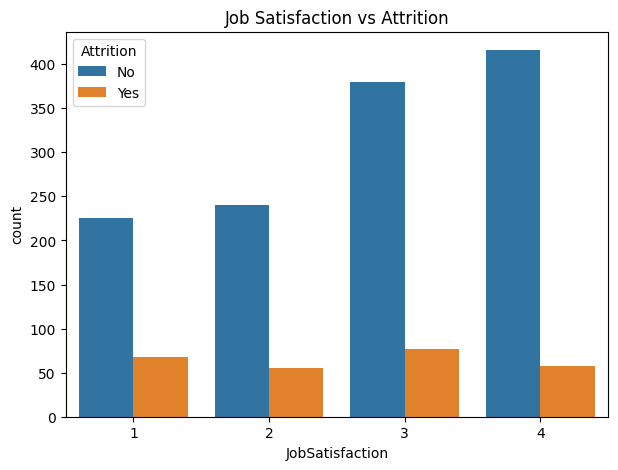

In [17]:
plt.figure(figsize=(7,5))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=data)
plt.title("Job Satisfaction vs Attrition")
plt.show()

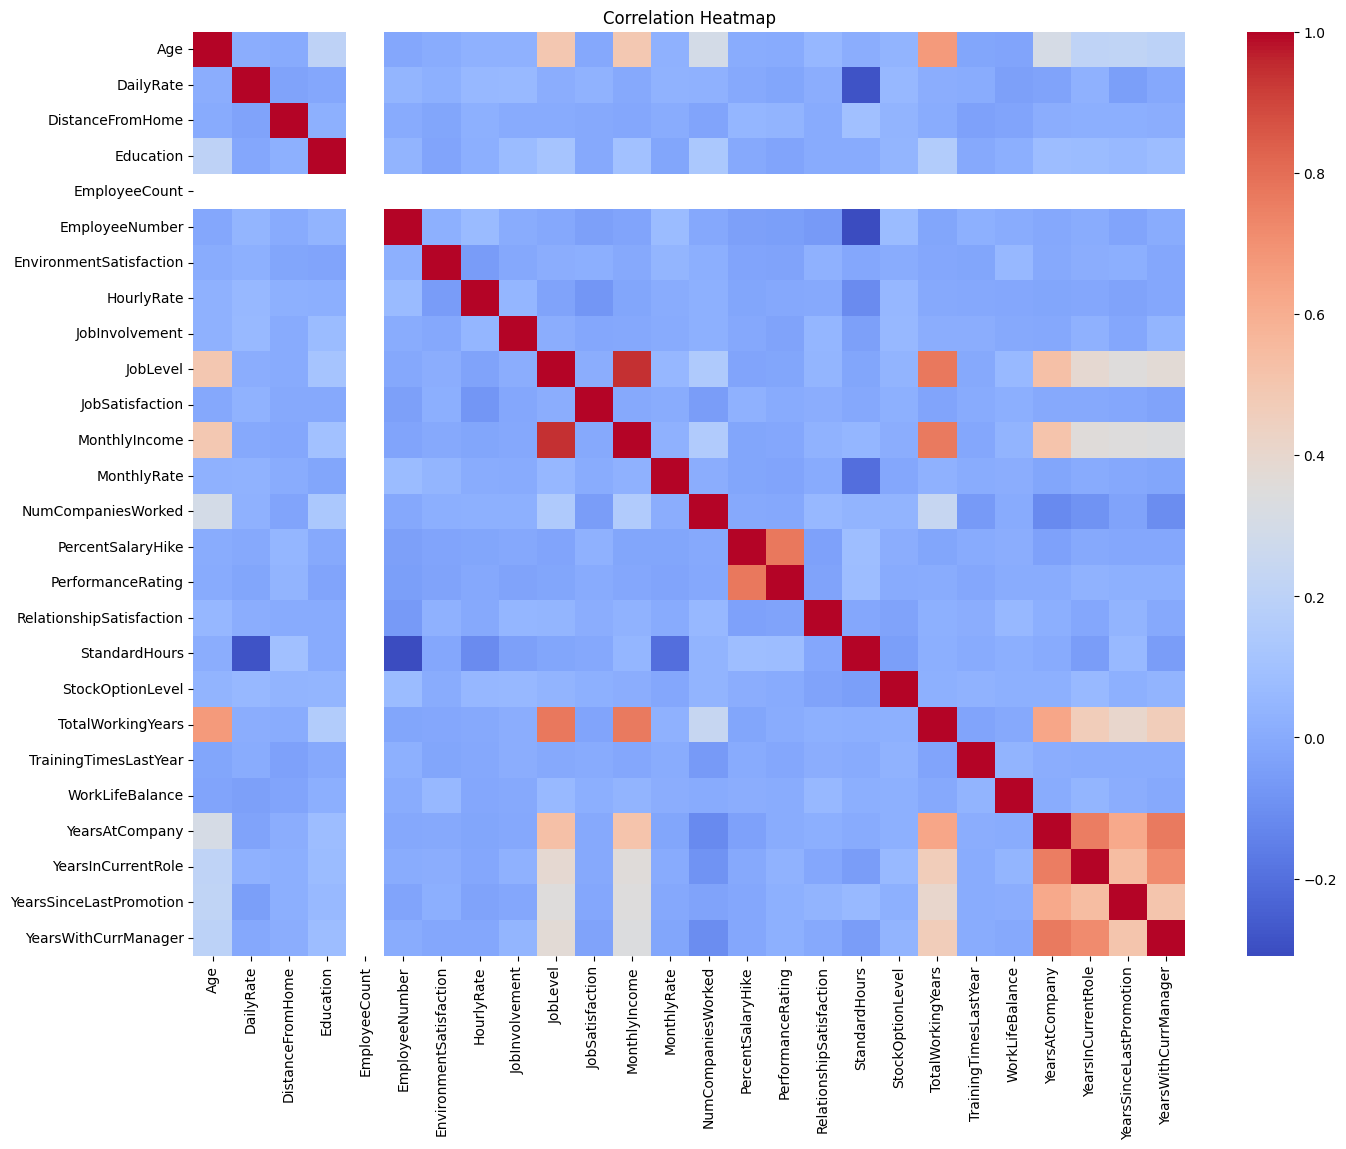

In [18]:
plt.figure(figsize=(16,12))

sns.heatmap(
    data.select_dtypes(include=['int64','float64']).corr(),
    annot=False,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

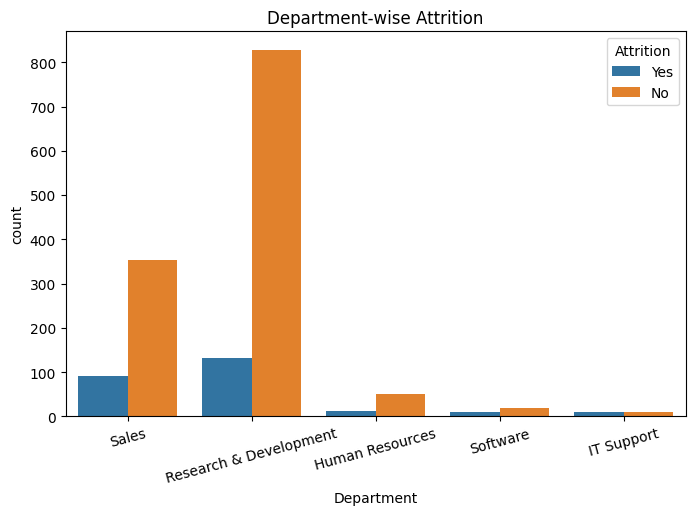

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Department',
    hue='Attrition',
    data=data
)

plt.xticks(rotation=15)
plt.title("Department-wise Attrition")
plt.show()

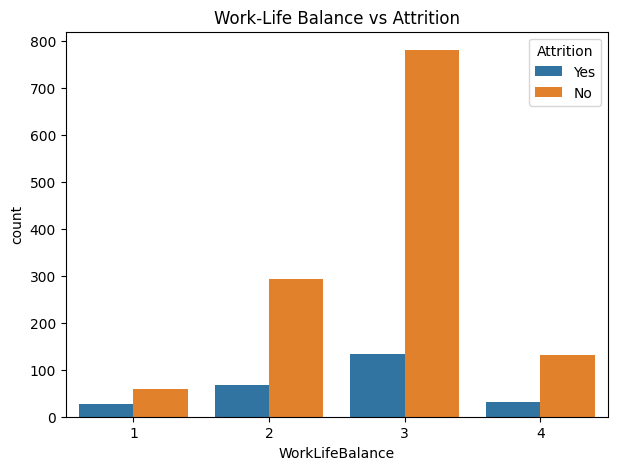

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=data
)

plt.title("Work-Life Balance vs Attrition")
plt.show()

In [21]:
from sklearn.metrics import accuracy_score

rf_acc = accuracy_score(y_test, rf_predictions)
lr_acc = accuracy_score(y_test, lr_predictions)
svm_acc = accuracy_score(y_test, svm_predictions)

print("Random Forest :", rf_acc)
print("Logistic Regression :", lr_acc)
print("SVM :", svm_acc)

NameError: name 'lr_predictions' is not defined

In [22]:
logreg_classifier = LogisticRegression()
logreg_classifier.fit(X_train, y_train)

LogisticRegression()

In [23]:
lr_predictions = logreg_classifier.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

# Predictions
rf_predictions = rf_classifier.predict(X_test)
lr_predictions = logreg_classifier.predict(X_test)
svm_predictions = svm_classifier.predict(X_test)

# Accuracy
rf_acc = accuracy_score(y_test, rf_predictions)
lr_acc = accuracy_score(y_test, lr_predictions)
svm_acc = accuracy_score(y_test, svm_predictions)

print("Random Forest Accuracy :", rf_acc)
print("Logistic Regression Accuracy :", lr_acc)
print("SVM Accuracy :", svm_acc)

Random Forest Accuracy : 0.8519736842105263
Logistic Regression Accuracy : 0.8782894736842105
SVM Accuracy : 0.868421052631579


In [26]:
models = {
    "Random Forest": rf_acc,
    "Logistic Regression": lr_acc,
    "Support Vector Machine": svm_acc
}

best_model = max(models, key=models.get)

print("\nModel Comparison")
print("-"*40)

for model, score in models.items():
    print(f"{model:25} : {score:.2%}")

print("\nBest Model:", best_model)
print("Accuracy:", f"{models[best_model]:.2%}")


Model Comparison
----------------------------------------
Random Forest             : 85.20%
Logistic Regression       : 87.83%
Support Vector Machine    : 86.84%

Best Model: Logistic Regression
Accuracy: 87.83%


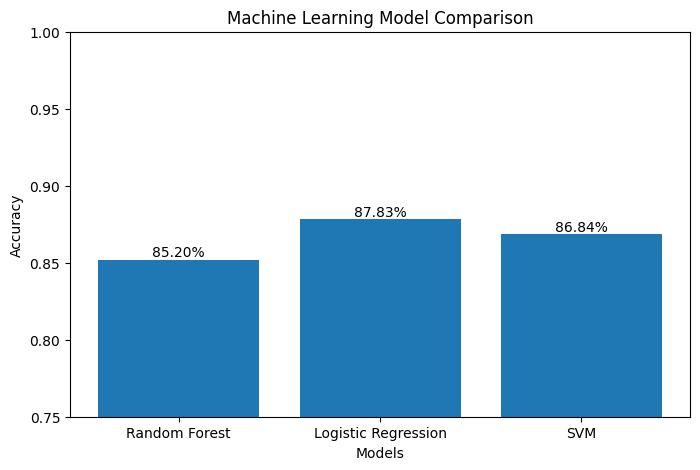

In [27]:
import matplotlib.pyplot as plt

models = ["Random Forest", "Logistic Regression", "SVM"]
accuracies = [rf_acc, lr_acc, svm_acc]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2%}",
        ha='center',
        va='bottom'
    )

plt.ylim(0.75, 1.0)
plt.show()

In [28]:
import pickle

pickle.dump(logreg_classifier, open("Best_Employee_Attrition_Model.pkl", "wb"))

print("Best model saved successfully!")

Best model saved successfully!


In [29]:
# ==========================================
# DATASET OVERVIEW
# ==========================================

print("="*60)
print("EMPLOYEE ATTRITION DATASET OVERVIEW")
print("="*60)

print(f"\nNumber of Rows        : {data.shape[0]}")
print(f"Number of Columns     : {data.shape[1]}")

print("\nNumerical Features :", len(data.select_dtypes(include=['int64','float64']).columns))
print("Categorical Features:", len(data.select_dtypes(include=['object']).columns))

print("\nTarget Variable Distribution")
print(data['Attrition'].value_counts())

print("\nTarget Variable Percentage")
print((data['Attrition'].value_counts(normalize=True)*100).round(2))

print("\nDuplicate Rows:", data.duplicated().sum())

print("\nMissing Values:", data.isnull().sum().sum())

print("="*60)

EMPLOYEE ATTRITION DATASET OVERVIEW

Number of Rows        : 1520
Number of Columns     : 35

Numerical Features : 26
Categorical Features: 9

Target Variable Distribution
Attrition
No     1262
Yes     258
Name: count, dtype: int64

Target Variable Percentage
Attrition
No     83.03
Yes    16.97
Name: proportion, dtype: float64

Duplicate Rows: 0

Missing Values: 0


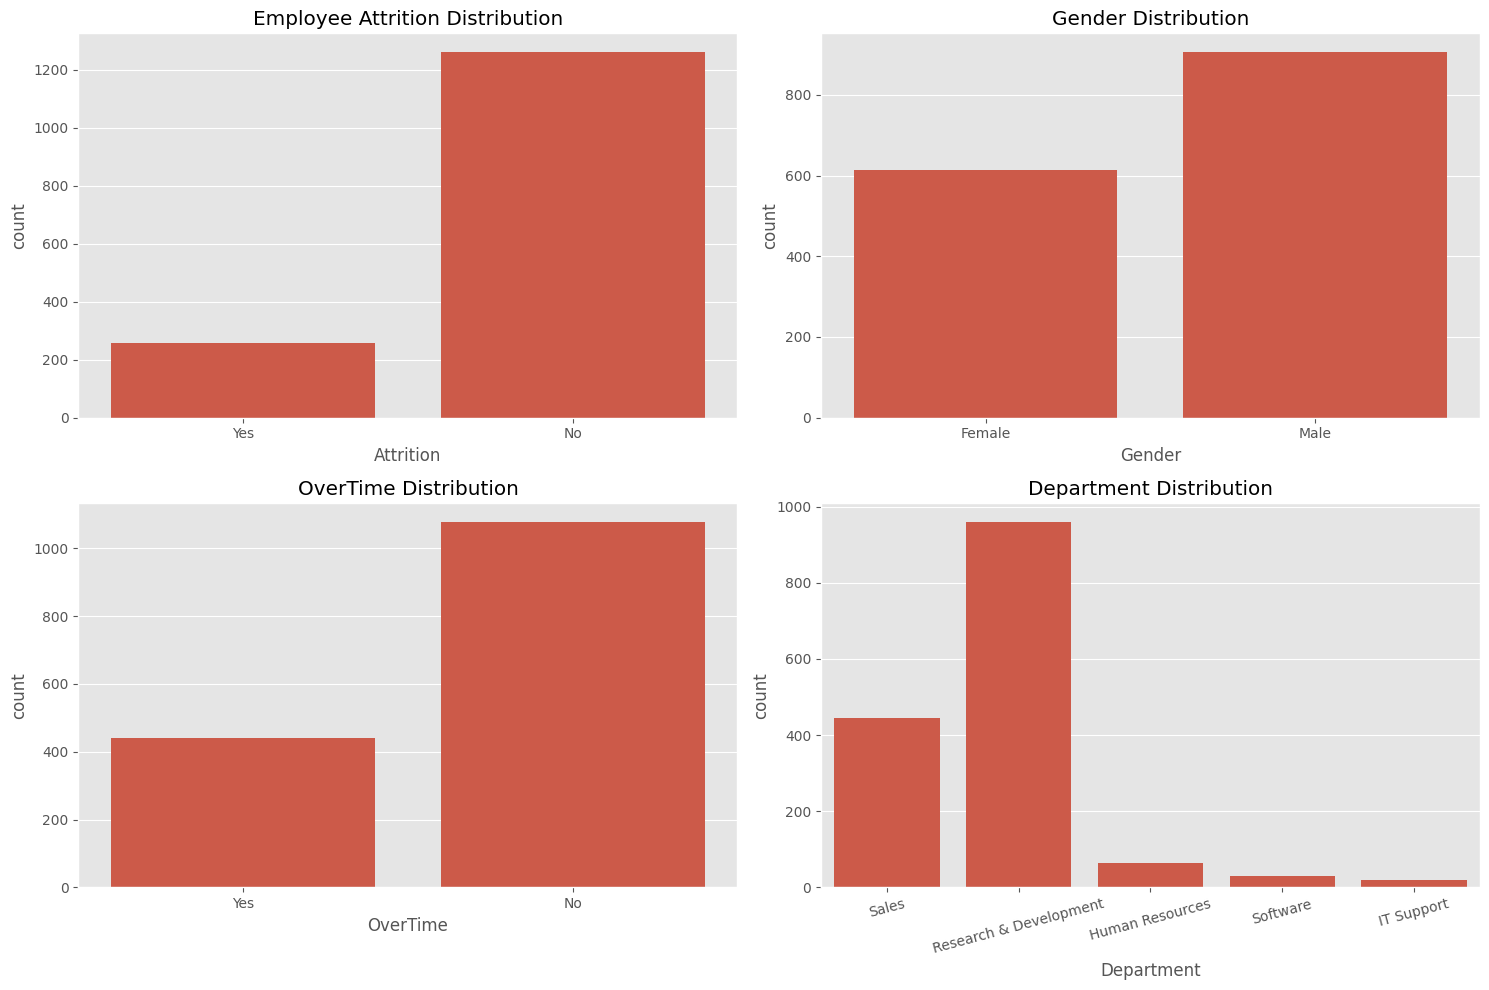

In [30]:
# ==========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Attrition Distribution
sns.countplot(x='Attrition', data=data, ax=axes[0,0])
axes[0,0].set_title("Employee Attrition Distribution")

# 2. Gender Distribution
sns.countplot(x='Gender', data=data, ax=axes[0,1])
axes[0,1].set_title("Gender Distribution")

# 3. OverTime Distribution
sns.countplot(x='OverTime', data=data, ax=axes[1,0])
axes[1,0].set_title("OverTime Distribution")

# 4. Department Distribution
sns.countplot(x='Department', data=data, ax=axes[1,1])
axes[1,1].set_title("Department Distribution")
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

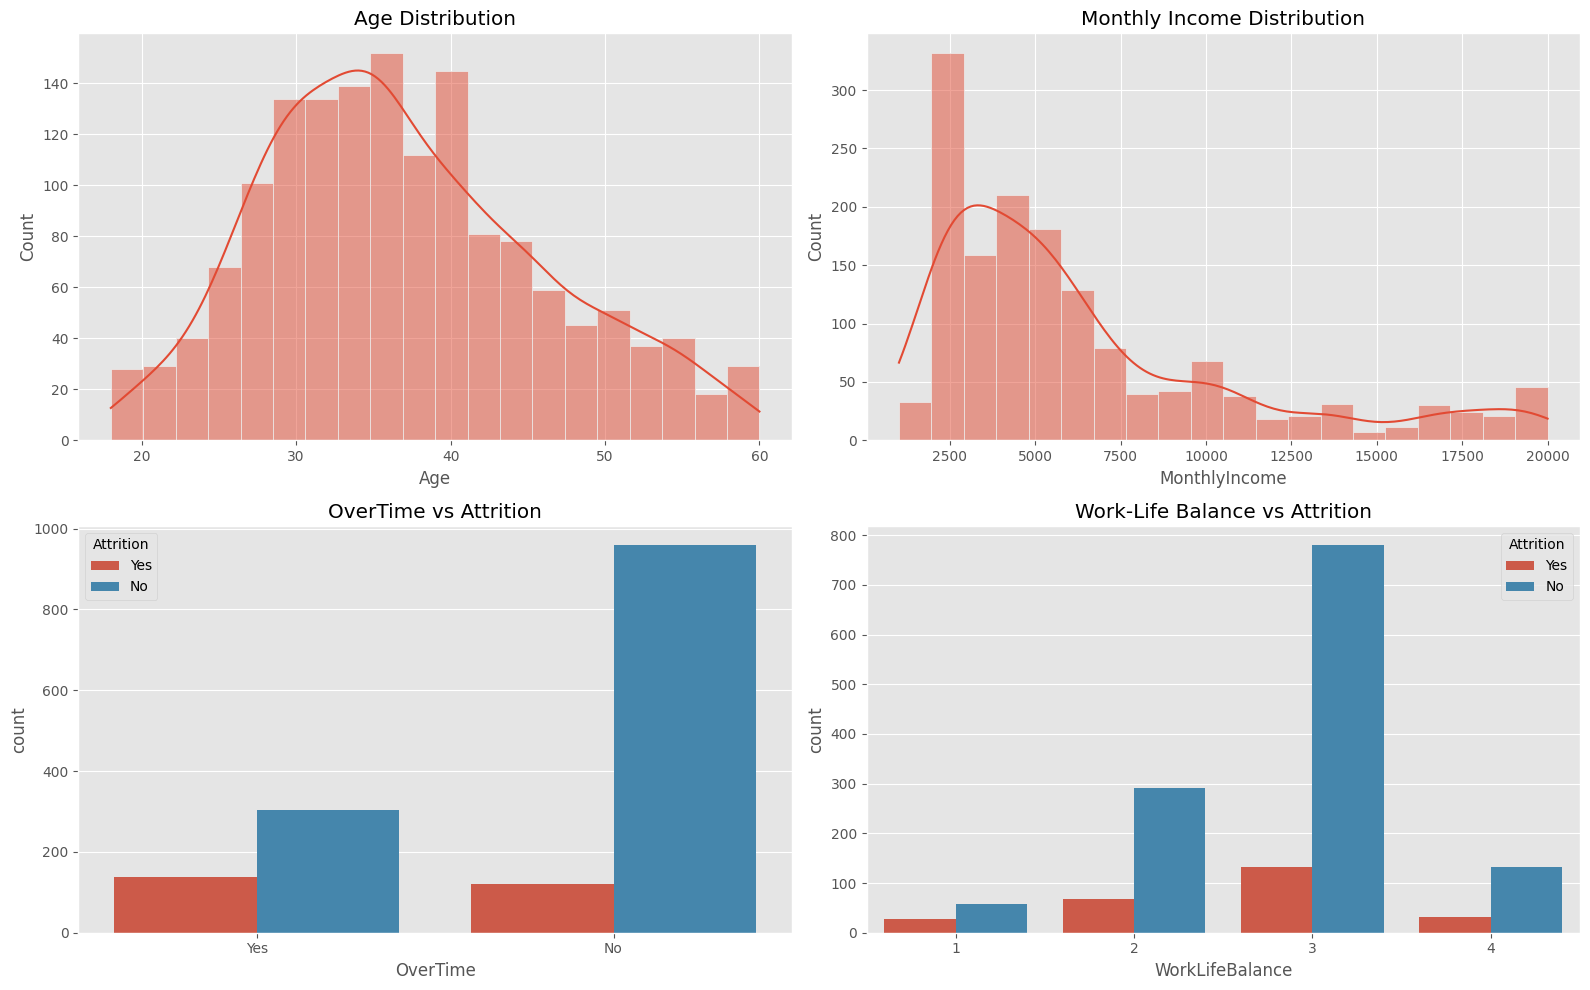

In [31]:
# ==========================================
# ADVANCED EXPLORATORY DATA ANALYSIS
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Age Distribution
sns.histplot(data['Age'], bins=20, kde=True, ax=axes[0,0])
axes[0,0].set_title("Age Distribution")

# 2. Monthly Income Distribution
sns.histplot(data['MonthlyIncome'], bins=20, kde=True, ax=axes[0,1])
axes[0,1].set_title("Monthly Income Distribution")

# 3. Attrition vs OverTime
sns.countplot(x='OverTime', hue='Attrition', data=data, ax=axes[1,0])
axes[1,0].set_title("OverTime vs Attrition")

# 4. Attrition vs Work-Life Balance
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=data, ax=axes[1,1])
axes[1,1].set_title("Work-Life Balance vs Attrition")

plt.tight_layout()
plt.show()

Top 10 Most Important Features
                    Feature  Importance
2             MonthlyIncome    0.172768
9            EmployeeNumber    0.151306
0                       Age    0.134160
3          DistanceFromHome    0.109998
5            YearsAtCompany    0.104049
10             OverTime_Yes    0.066002
8   YearsSinceLastPromotion    0.057020
1           JobSatisfaction    0.051772
4           WorkLifeBalance    0.045913
6            JobInvolvement    0.045202


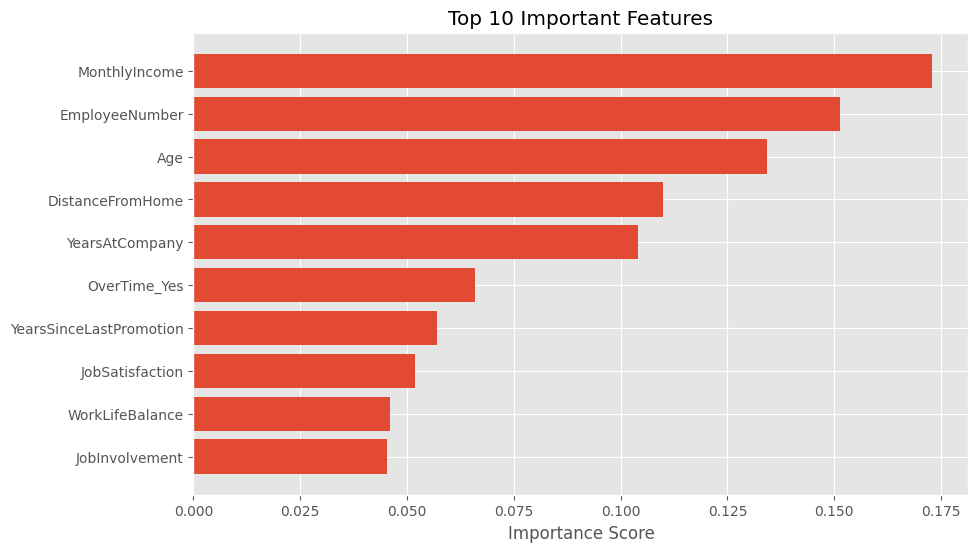

In [33]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_classifier.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Features")
print(importance.head(10))

plt.figure(figsize=(10,6))
plt.barh(
    importance['Feature'][:10],
    importance['Importance'][:10]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

In [36]:
# ==========================================
# IMPROVED CROSS VALIDATION
# ==========================================

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
logreg_classifier = LogisticRegression(max_iter=5000)
# Increase max_iter to avoid convergence warning
logreg_cv = LogisticRegression(max_iter=2000)

print("="*60)
print("STRATIFIED CROSS VALIDATION")
print("="*60)

rf_scores = cross_val_score(rf_classifier, X, y, cv=cv)
lr_scores = cross_val_score(logreg_cv, X, y, cv=cv)
svm_scores = cross_val_score(svm_classifier, X, y, cv=cv)

print("\nRandom Forest")
print(rf_scores)
print("Average Accuracy :", rf_scores.mean())

print("\nLogistic Regression")
print(lr_scores)
print("Average Accuracy :", lr_scores.mean())

print("\nSupport Vector Machine")
print(svm_scores)
print("Average Accuracy :", svm_scores.mean())

STRATIFIED CROSS VALIDATION


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Random Forest
[0.85526316 0.84868421 0.82565789 0.84539474 0.85197368]
Average Accuracy : 0.8453947368421053

Logistic Regression
[0.84868421 0.84210526 0.85526316 0.85197368 0.875     ]
Average Accuracy : 0.8546052631578946

Support Vector Machine
[0.82894737 0.82894737 0.82894737 0.83223684 0.83223684]
Average Accuracy : 0.8302631578947368


In [37]:
# ==========================================
# HYPERPARAMETER TUNING - RANDOM FOREST
# ==========================================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("="*60)
print("BEST PARAMETERS")
print("="*60)
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(round(grid_search.best_score_,4))

BEST PARAMETERS
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation Score:
0.8413


In [38]:
# ==========================================
# EVALUATE THE TUNED MODEL
# ==========================================

best_rf = grid_search.best_estimator_

best_predictions = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score

best_accuracy = accuracy_score(y_test, best_predictions)

print("="*60)
print("TUNED RANDOM FOREST ACCURACY")
print("="*60)

print("Accuracy :", round(best_accuracy*100,2), "%")

TUNED RANDOM FOREST ACCURACY
Accuracy : 84.87 %


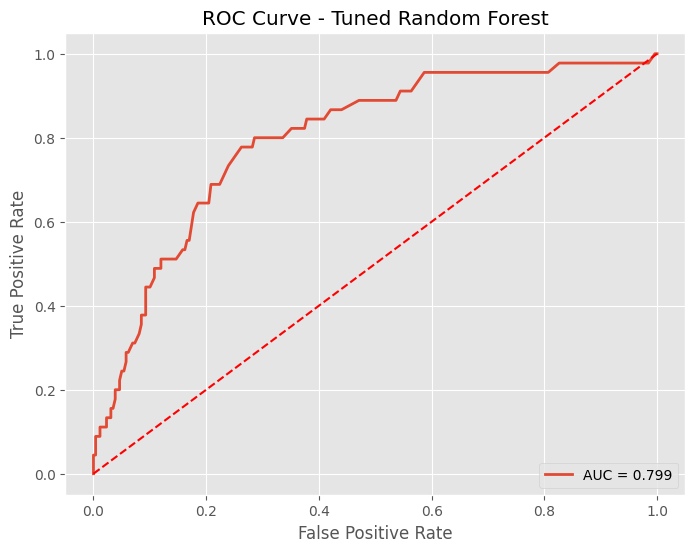

AUC Score : 0.7989


In [39]:
# ==========================================
# ROC CURVE & AUC SCORE
# ==========================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Use the tuned Random Forest model
y_prob = best_rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", linewidth=2)
plt.plot([0,1], [0,1], '--', color='red')

plt.title("ROC Curve - Tuned Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print(f"AUC Score : {auc_score:.4f}")

In [40]:
X = pd.get_dummies(X, drop_first=True)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
X = data.drop('Attrition', axis=1)

In [44]:
X = pd.get_dummies(...)

...

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
X = pd.get_dummies(X, drop_first=True)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [46]:
X = ...
y = ...

In [48]:
# ==========================================
# MODEL PERFORMANCE SUMMARY
# ==========================================

import pandas as pd

summary = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression",
        "Support Vector Machine"
    ],
    "Test Accuracy": [
        rf_acc,
        lr_acc,
        svm_acc
    ],
    "Cross Validation Accuracy": [
        rf_scores.mean(),
        lr_scores.mean(),
        svm_scores.mean()
    ]
})

summary["Test Accuracy"] = (summary["Test Accuracy"]*100).round(2)
summary["Cross Validation Accuracy"] = (summary["Cross Validation Accuracy"]*100).round(2)

print("="*65)
print("MODEL PERFORMANCE SUMMARY")
print("="*65)

display(summary)

MODEL PERFORMANCE SUMMARY


,Model,Test Accuracy,Cross Validation Accuracy
0,Random Forest,85.20,84.54
1,Logistic Regression,87.83,85.46
2,Support Vector Machine,86.84,83.03


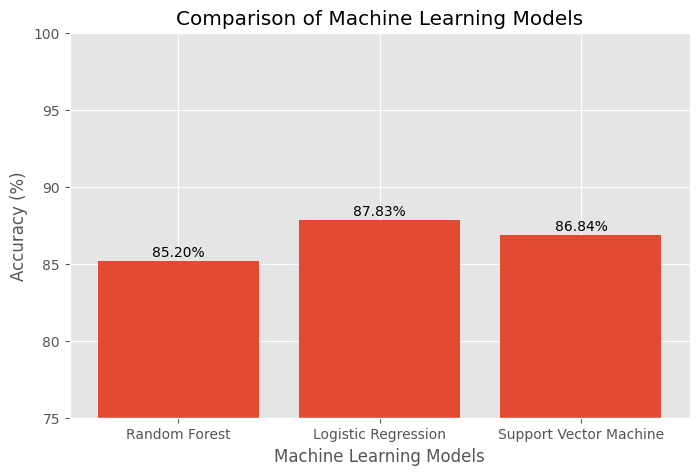

In [50]:
# ==========================================
# MODEL COMPARISON CHART
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(summary["Model"], summary["Test Accuracy"])

plt.ylabel("Accuracy (%)")
plt.xlabel("Machine Learning Models")
plt.title("Comparison of Machine Learning Models")

for i, value in enumerate(summary["Test Accuracy"]):
    plt.text(i, value+0.3, f"{value:.2f}%", ha='center')

plt.ylim(75,100)

plt.show()